<a href="https://colab.research.google.com/github/NABI-SNU/book/blob/main/tutorials/Session_2_BayesianInference/instructor/Tutorial2.ipynb" target="_blank"><img alt="Open In Colab" src="https://colab.research.google.com/assets/colab-badge.svg"/></a>   <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/NABI-SNU/book/main/tutorials/Session_2_BayesianInference/instructor/Tutorial2.ipynb" target="_blank"><img alt="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"/></a>


# Tutorial 2 (Instructor): OLS / Ridge / Lasso — solutions

**Session 2: Bayesian Inference** · **NABI-SNU**

This notebook mirrors the student worksheet, with each **Exercise** followed by a worked **Solution**.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sympy import symbols, log, simplify, sqrt, pi

from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True})


---

## Exercise 1 — Gaussian likelihood (scalar toy model)

Assume $y_i = \beta x_i + \varepsilon_i$ with $\varepsilon_i \stackrel{\text{iid}}{\sim}\mathcal{N}(0,\sigma^2)$, $i=1,\dots,n$.

1. Write the likelihood $p(\mathbf{y}\mid \beta, \sigma)$ (ignore constants w.r.t. $\beta$).
2. Show the **negative log-likelihood** is proportional to $\sum_i (y_i - \beta x_i)^2$ (up to $\sigma$).
3. In SymPy, define symbols for $\beta, \sigma$ and $(x_i, y_i)_{i=1}^3$ and form $\log p(\mathbf{y}\mid \beta)$. Expand it and identify the quadratic in $\beta$ — the coefficient comes from $\sum_i x_i^2/(2\sigma^2)$.


## Solution 1 — Gaussian likelihood

For $\mathbf{y}=\mathbf{X}\beta + \boldsymbol\varepsilon$, $\boldsymbol\varepsilon\sim\mathcal{N}(\mathbf{0},\sigma^2 I)$,
$$
p(\mathbf{y}\mid \beta,\sigma^2) = (2\pi\sigma^2)^{-n/2}\exp\!\left(-\frac{1}{2\sigma^2}\|\mathbf{y}-\mathbf{X}\beta\|_2^2\right).
$$
So **MLE** minimizes the **RSS** $\|\mathbf{y}-\mathbf{X}\beta\|_2^2$ (OLS).

SymPy illustration with $n=3$:


In [3]:
beta, sig = symbols("beta sigma", positive=True)
x1, x2, x3 = symbols("x1 x2 x3", real=True)
y1, y2, y3 = symbols("y1 y2 y3", real=True)

r1, r2, r3 = y1 - beta * x1, y2 - beta * x2, y3 - beta * x3
rss = r1**2 + r2**2 + r3**2

log_like = -3 * log(sig * sqrt(2 * pi)) - rss / (2 * sig**2)
log_like


-3*log(sqrt(2)*sqrt(pi)*sigma) - ((-beta*x1 + y1)**2 + (-beta*x2 + y2)**2 + (-beta*x3 + y3)**2)/(2*sigma**2)

In [4]:
simplify(log_like.expand())


(-beta**2*x1**2 - beta**2*x2**2 - beta**2*x3**2 + 2*beta*x1*y1 + 2*beta*x2*y2 + 2*beta*x3*y3 - y1**2 - y2**2 - y3**2 - log((2*pi*sigma**2)**(3*sigma**2)))/(2*sigma**2)

---

## Exercise 2 — Gaussian prior → Ridge (MAP)

Place a prior $\beta \sim \mathcal{N}(0, \tau^2)$ (independent of the data model).

1. Write $\log p(\beta)$ up to constants.
2. Form $\log p(\beta) + \log p(\mathbf{y}\mid \beta)$ and identify the **MAP** as minimizing
   $$\|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \lambda \|\beta\|_2^2$$
   with $\lambda = \sigma^2 / \tau^2$.
3. *(NumPy)* For a small design matrix $\mathbf{X}$ and vector $\mathbf{y}$, compute the **Ridge** closed form
   $\hat\beta = (\mathbf{X}^\top \mathbf{X} + \lambda I)^{-1}\mathbf{X}^\top \mathbf{y}$
   and compare to plain OLS when $\lambda \to 0$.


## Solution 2 — Gaussian prior gives Ridge MAP

Prior $\beta\sim\mathcal{N}(0,\tau^2)$ (scalar):
$\log p(\beta) = -\frac{\beta^2}{2\tau^2} + \text{const}$.

Up to an additive constant,
$$
\log p(\mathbf{y}\mid\beta) + \log p(\beta)
\propto -\frac{1}{2\sigma^2}\|\mathbf{y}-\mathbf{X}\beta\|_2^2 - \frac{1}{2\tau^2}\|\beta\|_2^2.
$$
Multiplying by $-2\sigma^2$ gives the Ridge objective $\|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \lambda\|\beta\|_2^2$ with $\lambda = \sigma^2/\tau^2$.

So the **MAP** equals **Ridge** with that $\lambda$.

**Closed form.** Minimize $Q(\beta) = \|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \lambda\|\beta\|_2^2$. Then $\nabla_\beta Q = -2\mathbf{X}^{\mathsf T}(\mathbf{y}-\mathbf{X}\beta) + 2\lambda\beta = \mathbf{0}$, hence $(\mathbf{X}^{\mathsf T}\mathbf{X} + \lambda \mathbf{I})\beta = \mathbf{X}^{\mathsf T}\mathbf{y}$ and
$$\hat{\beta} = (\mathbf{X}^{\mathsf T}\mathbf{X} + \lambda \mathbf{I})^{-1}\mathbf{X}^{\mathsf T}\mathbf{y}$$
(invertible for any $\lambda > 0$). When $\lambda \to 0$ and $\mathbf{X}^{\mathsf T}\mathbf{X}$ is nonsingular, $\hat{\beta} \to (\mathbf{X}^{\mathsf T}\mathbf{X})^{-1}\mathbf{X}^{\mathsf T}\mathbf{y}$ (OLS).


In [6]:
rng = np.random.default_rng(1)
n, p = 50, 3
X = rng.normal(size=(n, p))
beta_true = np.array([1.5, -0.5, 0.0])
y = X @ beta_true + 0.3 * rng.normal(size=n)

lam = 0.5
I = np.eye(p)

beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
beta_ridge = np.linalg.solve(X.T @ X + lam * I, X.T @ y)

print("OLS:  ", beta_ols)
print("Ridge:", beta_ridge)
print("(true)", beta_true)

OLS:   [ 1.62655952 -0.41414537  0.04486854]
Ridge: [ 1.60509211 -0.40884855  0.04118358]
(true) [ 1.5 -0.5  0. ]


---

## Exercise 3 — Laplace prior → Lasso (MAP)

Use prior $p(\beta) \propto \exp(-\alpha |\beta|)$ (Laplace with rate $\alpha$).

1. Write the MAP objective as minimizing **MSE + $\ell_1$ penalty**, $\|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \lambda \|\beta\|_1$ with $\lambda = 2\sigma^2 \alpha$.
2. Explain in one sentence why the **non-differentiability** of $|\beta|$ at zero encourages **exact zeros** of coefficients.
3. *(Plot)* On a grid $(\beta_1, \beta_2)$, compare **contours** of $\beta_1^2 + \beta_2^2$ ($\ell_2^2$) vs $|\beta_1|+|\beta_2|$ ($\ell_1$) and notice the **diamond** corners of the $\ell_1$ contours.


## Solution 3 — Laplace prior gives Lasso MAP

Prior $p(\beta)\propto \frac{\alpha}{2}\exp(-\alpha|\beta|)$ gives
$\log p(\beta) = -\alpha|\beta| + \text{const}$.

MAP maximizes $\log p(\mathbf{y}\mid\beta) + \log p(\beta)$, i.e. minimizes
$$
\frac{1}{2\sigma^2}\|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \alpha\|\beta\|_1
\;\;\Longleftrightarrow\;\;
\|\mathbf{y}-\mathbf{X}\beta\|_2^2 + \lambda\|\beta\|_1
$$
with $\lambda = 2\sigma^2\alpha$.

**Geometric intuition.** Below we plot the contours of the two penalties. The $\ell_1$ penalty's diamond corners on the axes are why the Lasso MAP often sits **exactly** on a sparse vertex, producing zeros in the coefficient vector.


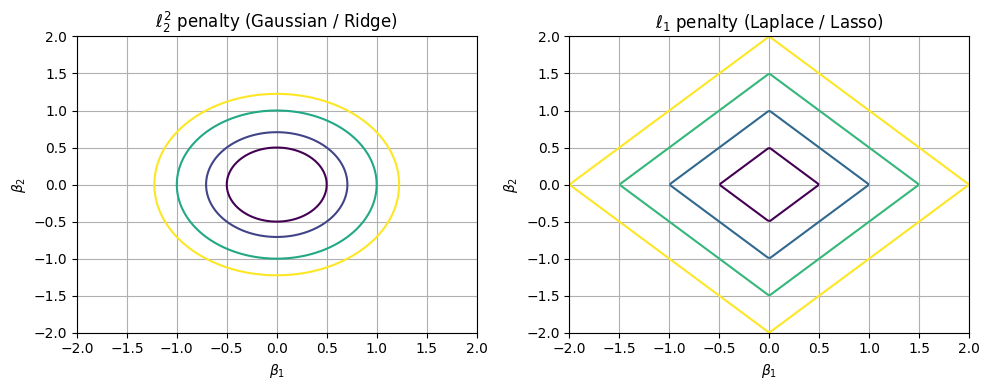

In [7]:
b1 = np.linspace(-2, 2, 200)
b2 = np.linspace(-2, 2, 200)
B1, B2 = np.meshgrid(b1, b2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].contour(B1, B2, B1**2 + B2**2, levels=[0.25, 0.5, 1, 1.5])
axes[0].set_title(r"$\ell_2^2$ penalty (Gaussian / Ridge)")
axes[0].set_xlabel(r"$\beta_1$")
axes[0].set_ylabel(r"$\beta_2$")

axes[1].contour(B1, B2, np.abs(B1) + np.abs(B2), levels=[0.5, 1, 1.5, 2])
axes[1].set_title(r"$\ell_1$ penalty (Laplace / Lasso)")
axes[1].set_xlabel(r"$\beta_1$")
axes[1].set_ylabel(r"$\beta_2$")
plt.tight_layout()
plt.show()


---

## Exercise 4 — OLS vs Ridge vs Lasso on noisy polynomial data

We generate noisy samples of $f(x) = \sin(1.5\pi x)$ on $x\in[0,1]$ and fit a **degree-12 polynomial** with three estimators:

- **OLS** — no penalty (typically overfits in this setup).
- **Ridge** ($\ell_2^2$ penalty) — shrinks coefficients smoothly.
- **Lasso** ($\ell_1$ penalty) — sets several coefficients **exactly to zero**.

You will:

1. Build polynomial features and fit all three models.
2. Plot the fitted curves against the true function.
3. Compare the **coefficients** as a bar chart (note Lasso's zeros).
4. *(Optional)* Trace **regularization paths** for Ridge and Lasso as $\alpha$ varies.


## Solution 4 — Polynomial fit comparison

We sample $y_i = \sin(1.5\pi x_i) + \varepsilon_i$ with $\varepsilon_i \sim \mathcal{N}(0, 0.15^2)$ and fit a degree-12 polynomial. Standardizing the polynomial features keeps Ridge and Lasso well-behaved.

- **OLS** has no penalty and therefore exploits all 12 features to wiggle through the noise.
- **Ridge** ($\alpha = 1$) shrinks every coefficient — the curve becomes much smoother but most coefficients remain non-zero.
- **Lasso** ($\alpha = 0.01$) sets several coefficients to **exact zero**, performing implicit feature selection.


/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/Caskroom/miniconda/base/envs/book-py39/lib/python3.9/

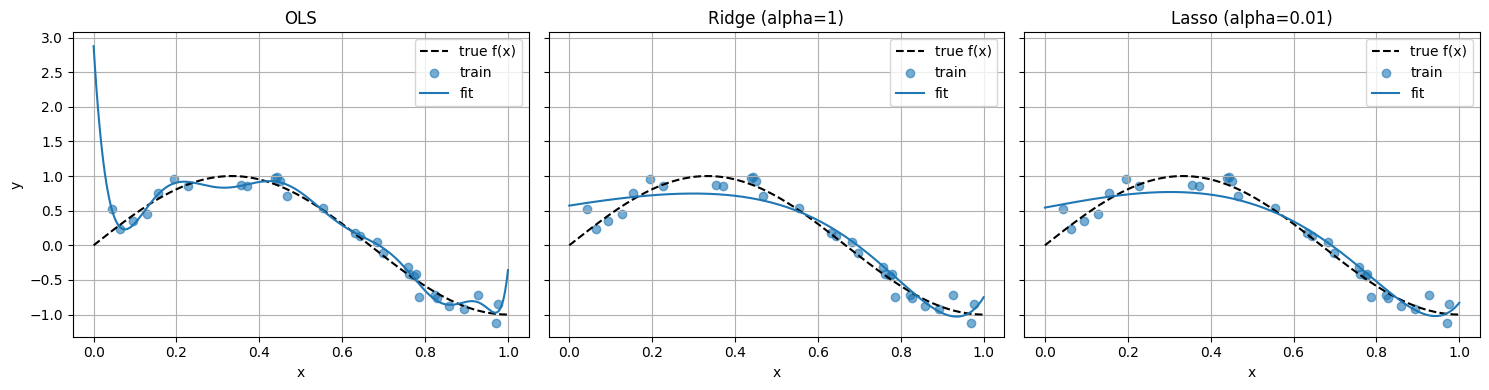

In [14]:
rng = np.random.default_rng(42)
n_train = 30
x_train = np.sort(rng.uniform(0.0, 1.0, n_train))
y_train = np.sin(1.5 * np.pi * x_train) + 0.15 * rng.normal(size=n_train)

x_plot = np.linspace(0.0, 1.0, 300)
y_true = np.sin(1.5 * np.pi * x_plot)

degree = 12


def pipeline_for(model):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", model),
    ])


ols = pipeline_for(LinearRegression()).fit(x_train.reshape(-1, 1), y_train)
ridge = pipeline_for(Ridge(alpha=1.0)).fit(x_train.reshape(-1, 1), y_train)
lasso = pipeline_for(Lasso(alpha=0.01, max_iter=20000)).fit(
    x_train.reshape(-1, 1), y_train
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, model, name in zip(
    axes,
    [ols, ridge, lasso],
    ["OLS", "Ridge (alpha=1)", "Lasso (alpha=0.01)"],
):
    ax.plot(x_plot, y_true, "k--", label="true f(x)")
    ax.scatter(x_train, y_train, alpha=0.6, label="train")
    ax.plot(x_plot, model.predict(x_plot.reshape(-1, 1)), label="fit")
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.legend()
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()


### Coefficient magnitudes

The bar chart below uses a **symlog** y-axis (`plt.yscale("symlog", linthresh=0.01)`) so large OLS coefficients do not squash the Ridge and Lasso bars. Notice how Ridge **shrinks** every coefficient while Lasso drives many of them **exactly to zero**.


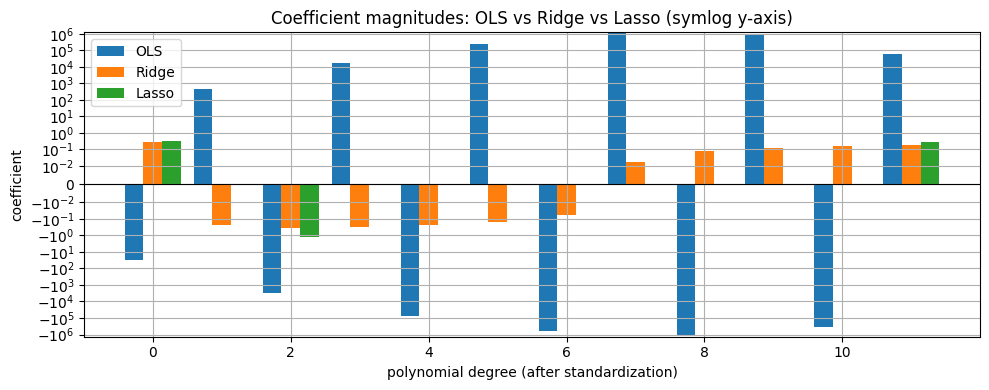

Lasso zeroed 9 of 12 coefficients.


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
idx = np.arange(degree)
width = 0.27
ax.bar(idx - width, ols.named_steps["model"].coef_,   width, label="OLS")
ax.bar(idx,         ridge.named_steps["model"].coef_, width, label="Ridge")
ax.bar(idx + width, lasso.named_steps["model"].coef_, width, label="Lasso")
ax.axhline(0.0, color="k", linewidth=0.8)
ax.set_yscale("symlog", linthresh=0.01)
ax.set_xlabel("polynomial degree (after standardization)")
ax.set_ylabel("coefficient")
ax.set_title("Coefficient magnitudes: OLS vs Ridge vs Lasso (symlog y-axis)")
ax.legend()
plt.tight_layout()
plt.show()

n_zero_lasso = int(np.sum(np.isclose(lasso.named_steps["model"].coef_, 0.0)))
print(f"Lasso zeroed {n_zero_lasso} of {degree} coefficients.")
